Grid size: 10x10 | NumPy time: 0.0726s | CuPy GPU time: 0.5511s | Torch GPU time: 0.0806s
Grid size: 50x50 | NumPy time: 2.5107s | CuPy GPU time: 0.8576s | Torch GPU time: 0.1030s
Grid size: 100x100 | NumPy time: 8.0459s | CuPy GPU time: 0.5674s | Torch GPU time: 0.0783s
Grid size: 200x200 | NumPy time: 38.1262s | CuPy GPU time: 0.7059s | Torch GPU time: 0.0791s
Grid size: 300x300 | NumPy time: 82.3174s | CuPy GPU time: 0.8484s | Torch GPU time: 0.0796s


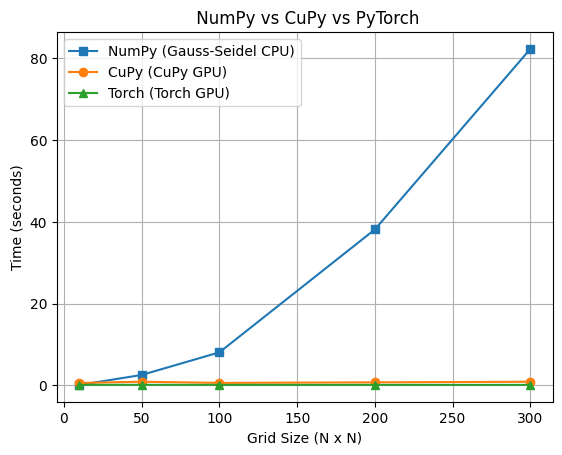

In [16]:

import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer as timer
import torch
import cupy as cp

def gauss_seidel(f):

    newf = f.copy()
    for i in range(1, newf.shape[0] - 1):
        for j in range(1, newf.shape[0] - 1):
            newf[i,j] = 0.25 * (newf[i,j+1] + newf[i, j-1]+
                                newf[i+1,j] + newf[i-1,j])

    return newf


def gauss_seidel_torch(f):
    newf = f.clone()

    newf = 0.25 * (torch.roll(f, shifts=1, dims=0)+
                       torch.roll(f, shifts=-1, dims=0)+
                       torch.roll(f, shifts=1, dims=1)+
                       torch.roll(f,shifts=-1, dims=1))



    return newf


def gauss_seidel_cupy(f):
    f = cp.array(f, dtype=cp.float64)
    newf = f.copy()


    newf[1:-1, 1:-1] = 0.25 * (
        cp.roll(f, shift=1, axis=0)[1:-1, 1:-1] +
        cp.roll(f, shift=-1, axis=0)[1:-1, 1:-1] +
        cp.roll(f, shift=1, axis=1)[1:-1, 1:-1] +
        cp.roll(f, shift=-1, axis=1)[1:-1, 1:-1]
    )

    return cp.asnumpy(newf)

def initialize(grid_sizes):
    times_numpy = []
    times_torch = []
    times_cupy = []

    for N in grid_sizes:
        f_numpy = np.random.rand(N, N).astype(np.float64)
        f_numpy[0, :] = f_numpy[-1, :] = f_numpy[:, 0] = f_numpy[:, -1] = 0
        f_torch = torch.tensor(f_numpy, dtype=torch.float64, device='cuda')
        f_cupy = cp.array(f_numpy.copy(), dtype=cp.float64)

        start_time = timer()
        for _ in range(1000):
            f_numpy = gauss_seidel(f_numpy)
        end_time = timer()
        times_numpy.append(end_time - start_time)


        start_time = timer()
        for _ in range(1000):
            f_torch = gauss_seidel_torch(f_torch)
        end_time = timer()
        times_torch.append(end_time - start_time)


        start_time = timer()
        for _ in range(1000):
            f_cupy = gauss_seidel_cupy(f_cupy)
        end_time = timer()
        times_cupy.append(end_time - start_time)

        print(f"Grid size: {N}x{N} | NumPy time: {times_numpy[-1]:.4f}s | CuPy GPU time: {times_cupy[-1]:.4f}s | Torch GPU time: {times_torch[-1]:.4f}s")

    return times_numpy, times_torch, times_cupy


if __name__ == "__main__":
    grid_sizes = [10, 50, 100, 200, 300]
    times_numpy, times_torch, times_cupy = initialize(grid_sizes)


    plt.plot(grid_sizes, times_numpy, marker='s', linestyle='-', label='NumPy (Gauss-Seidel CPU)')
    plt.plot(grid_sizes, times_cupy, marker='o', linestyle='-', label='CuPy (CuPy GPU)')
    plt.plot(grid_sizes, times_torch, marker='^', linestyle='-', label='Torch (Torch GPU)')
    plt.xlabel('Grid Size (N x N)')
    plt.ylabel('Time (seconds)')
    plt.title(' NumPy vs CuPy vs PyTorch')
    plt.legend()
    plt.grid()
    plt.show()







For the smallest Grid size, the GPUs are noticeably slower than the CPU (Numpy). This is because the overhead of transferring the data to the GPU and managing GPU resources is significant for small grid sizes.

For the largest grid size, the GPUs are much faster than Numpy.

PyTorch is highly optimized for GPU acceleration, which leads to better performance, especially for larger grid sizes.

